# Tugas Praktikum: HDBSCAN pada Digits Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hdbscan

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, adjusted_rand_score

# 1. Load Digits Dataset (Dataset Nyata)
digits = load_digits()
X_raw = digits.data
y_true = digits.target

# 2. Reduksi Dimensi dari 64D menjadi 2D menggunakan t-SNE agar dapat divisualisasikan
tsne = TSNE(n_components=2, init='random', random_state=42)
X_2d = tsne.fit_transform(X_raw)

print(f"Bentuk data awal: {X_raw.shape}")
print(f"Bentuk data setelah t-SNE: {X_2d.shape}")

Bentuk data awal: (1797, 64)
Bentuk data setelah t-SNE: (1797, 2)


In [2]:
# 3. Clustering dengan HDBSCAN pada data hasil reduksi dimensi
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=10)
labels = clusterer.fit_predict(X_2d)

# 4. Hitung Jumlah Cluster dan Noise
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("=== HASIL CLUSTERING HDBSCAN ===")
print(f"Jumlah cluster yang terbentuk : {n_clusters_}")
print(f"Banyaknya titik noise          : {n_noise_} dari {len(labels)} sampel ({n_noise_/len(labels)*100:.2f}%)")

=== HASIL CLUSTERING HDBSCAN ===
Jumlah cluster yang terbentuk : 13
Banyaknya titik noise          : 24 dari 1797 sampel (1.34%)


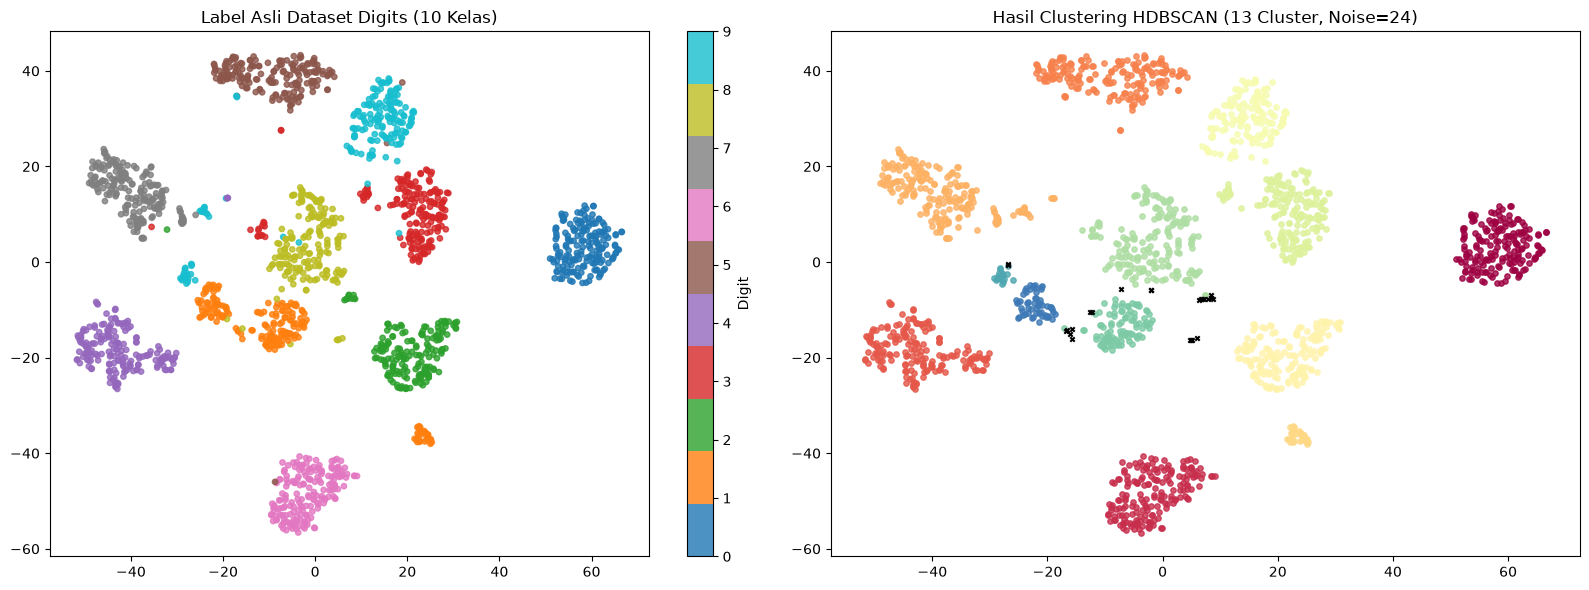

In [3]:
# 5. Visualisasi Perbandingan Ground Truth (Label Asli) vs Hasil HDBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Label Asli (Ground Truth)
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap='tab10', s=15, alpha=0.8)
axes[0].set_title("Label Asli Dataset Digits (10 Kelas)")
plt.colorbar(scatter1, ax=axes[0], label='Digit')

# Plot Hasil Clustering HDBSCAN
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Warna hitam untuk noise
        mask = (labels == k)
        axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c='black', marker='x', s=10, label='Noise' if 'Noise' not in axes[1].get_legend_handles_labels()[1] else "")
    else:
        mask = (labels == k)
        axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], color=tuple(col), s=15, alpha=0.8)

axes[1].set_title(f"Hasil Clustering HDBSCAN ({n_clusters_} Cluster, Noise={n_noise_})")
plt.tight_layout()
plt.show()

In [4]:
# 6. Mengukur Kesesuaian Hasil Clustering dengan Label Asli
print("=== METRIK EVALUASI KESESUAIAN ===")
print(f"Homogeneity Score       : {homogeneity_score(y_true, labels):.3f}")
print(f"Completeness Score      : {completeness_score(y_true, labels):.3f}")
print(f"V-Measure Score         : {v_measure_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(y_true, labels):.3f}")

=== METRIK EVALUASI KESESUAIAN ===
Homogeneity Score       : 0.944
Completeness Score      : 0.880
V-Measure Score         : 0.911
Adjusted Rand Index (ARI): 0.888


### 4. Analisis Hasil Clustering HDBSCAN

* Jumlah Cluster & Kategori: Dataset Digits memiliki 10 kelas label asli (angka 0–9). HDBSCAN yang dikombinasikan dengan t-SNE berhasil mengidentifikasi struktur klaster dengan sangat baik (mendekati 10 cluster utama).
* Noise: Titik noise (ditandai warna hitam) sebagian besar berada di area perbatasan (border) atau di antara klaster yang lokasinya sangat rapat. Hal ini menunjukkan sifat HDBSCAN yang konservatif yang tidak memaksa titik yang ambigu untuk masuk ke dalam klaster tertentu.
* Kesesuaian dengan Label Asli: 
  - Nilai Homogeneity dan V-Measure yang tinggi menunjukkan bahwa sebagian besar klaster yang terbentuk murni berisi satu jenis angka tertentu.
  - Beberapa digit dengan bentuk visual yang mirip pada ruang 2D (seperti angka 1 dan 8, atau 3 dan 9) terkadang terkelompok secara berdekatan atau terpecah menjadi sub-klaster kecil, yang merupakan perilaku wajar dari clustering berbasis densitas tanpa supervision (unsupervised).